# Martingais e Concentração — Notebook Completo
Este notebook contém:
1. Simulação da probabilidade empirical de violação do bound (Hoeffding/Azuma)
2. Bandas teóricas de Azuma–Hoeffding para a média empírica (intervalos de confiança não assintóticos)
3. Experimento com risco empírico de um classificador simples (concentração do erro)

Todas as figuras usam matplotlib (uma figura por célula) conforme solicitado.

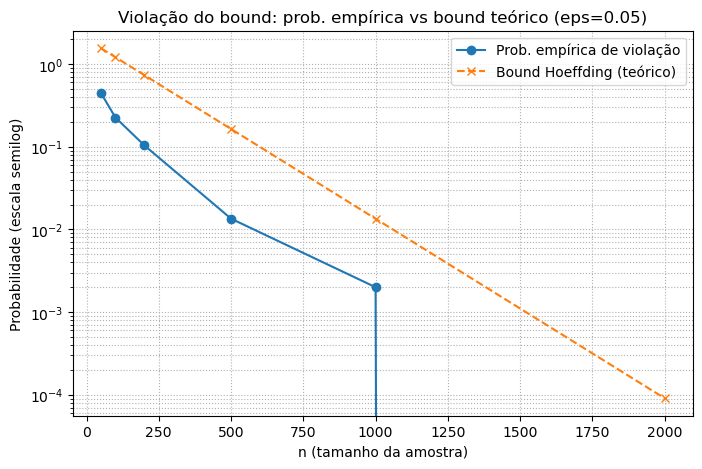

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt

np.random.seed(0)
plt.rcParams['figure.figsize'] = (8,5)

def hoeffding_bound(n, eps):
    # para variáveis em [0,1]: Pr(|mean-mu|>eps) <= 2 exp(-2 n eps^2)
    return 2*np.exp(-2*n*(eps**2))

def estimate_violation_probability(trials=2000, n_values=None, eps=0.05, dist='bernoulli', p=0.3):
    if n_values is None:
        n_values = [50,100,200,500,1000,2000]
    emp_probs = []
    bounds = []
    for n in n_values:
        violations = 0
        for t in range(trials):
            if dist=='bernoulli':
                X = np.random.binomial(1,p,size=n)
                mu = p
            elif dist=='uniform':
                X = np.random.uniform(0,1,size=n)
                mu = 0.5
            else:
                raise ValueError('dist desconhecida')
            mean = X.mean()
            if abs(mean-mu) > eps:
                violations += 1
        emp_prob = violations / trials
        emp_probs.append(emp_prob)
        bounds.append(hoeffding_bound(n, eps))
    return n_values, emp_probs, bounds

# Rodar a simulação
n_vals, emp_probs, bounds = estimate_violation_probability(trials=2000, eps=0.05, dist='bernoulli', p=0.3)

# Plot: prob. empírica vs bound teórico
plt.figure()
plt.semilogy(n_vals, emp_probs, marker='o', label='Prob. empírica de violação')
plt.semilogy(n_vals, bounds, marker='x', linestyle='--', label='Bound Hoeffding (teórico)')
plt.xlabel('n (tamanho da amostra)')
plt.ylabel('Probabilidade (escala semilog)')
plt.title('Violação do bound: prob. empírica vs bound teórico (eps=0.05)')
plt.legend()
plt.grid(True, which='both', ls=':')
plt.show()


## Bandas teóricas (Azuma/Hoeffding) para a média empírica
Mostramos a média acumulada (running mean) e a banda teórica para um nível de confiança \(1-\delta\).
Usamos a versão: \(Pr(|\hat{\mu}_n - \mu| > \varepsilon) \le 2e^{-2n\varepsilon^2}\). Assim
\(\varepsilon(n,\delta) = \sqrt{\frac{1}{2n}\ln\frac{2}{\delta}}\).


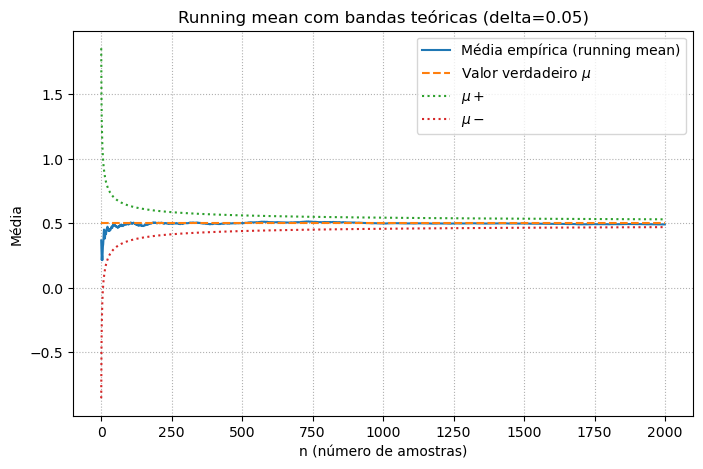

In [2]:
def plot_running_mean_with_bands(n=2000, dist='uniform', delta=0.05):
    if dist=='uniform':
        X = np.random.uniform(0,1,n)
        mu = 0.5
    elif dist=='bernoulli':
        p = 0.3
        X = np.random.binomial(1,p,size=n)
        mu = p
    else:
        raise ValueError('dist desconhecida')
    running_mean = np.cumsum(X) / (np.arange(n) + 1)
    eps_n = np.sqrt((1.0/(2*(np.arange(n)+1))) * np.log(2.0/delta))

    plt.figure()
    plt.plot(running_mean, label='Média empírica (running mean)')
    plt.plot([0,n-1],[mu,mu], linestyle='--', label='Valor verdadeiro $\mu$')
    plt.plot(mu + eps_n, linestyle=':', label='$\mu + \varepsilon(n,\delta)$')
    plt.plot(mu - eps_n, linestyle=':', label='$\mu - \varepsilon(n,\delta)$')
    plt.xlabel('n (número de amostras)')
    plt.ylabel('Média')
    plt.title(f'Running mean com bandas teóricas (delta={delta})')
    plt.legend()
    plt.grid(True, ls=':')
    plt.show()

plot_running_mean_with_bands(n=2000, dist='uniform', delta=0.05)


## Experimento: risco empírico de um classificador simples
Geramos dados com duas classes normais: 
- Classe 0: $X \sim \mathcal{N}(-1,1)$
- Classe 1: $X \sim \mathcal{N}(1,1)$

Usamos um classificador simples (threshold em 0): $h(x)=\mathbf{1}\{x>0\}$.
O erro verdadeiro (risco) pode ser calculado analiticamente e as perdas são em \([0,1]\), então podemos aplicar Hoeffding/Azuma para a perda média.


In [3]:
def normal_cdf(x):
    # CDF da normal padrão usando erf
    return 0.5 * (1 + math.erf(x / math.sqrt(2)))

def classifier_error_experiment(n=500, trials=1000, eps=0.03):
    # Parâmetros das classes
    mu0, mu1 = -1.0, 1.0
    sigma = 1.0
    # risco verdadeiro (simétrico, classes com prob 1/2)
    err0 = 1 - normal_cdf((0 - mu0)/sigma)
    err1 = normal_cdf((0 - mu1)/sigma)
    true_risk = 0.5*(err0 + err1)

    violations = 0
    for t in range(trials):
        # gerar conjunto de teste
        y = np.random.binomial(1, 0.5, size=n)
        x = np.where(y==1, np.random.normal(mu1, sigma, size=n), np.random.normal(mu0, sigma, size=n))
        preds = (x > 0).astype(int)
        losses = (preds != y).astype(float)
        emp_risk = losses.mean()
        if abs(emp_risk - true_risk) > eps:
            violations += 1
    emp_prob = violations / trials
    bound = hoeffding_bound(n, eps)
    return true_risk, emp_prob, bound

true_risk, emp_prob, bound = classifier_error_experiment(n=500, trials=2000, eps=0.03)
print(f'True risk (analítico): {true_risk:.4f}')
print(f'Probabilidade empírica de |emp_risk - true_risk| > 0.03: {emp_prob:.4f}')
print(f'Bound teórico Hoeffding: {bound:.4e}')


True risk (analítico): 0.1587
Probabilidade empírica de |emp_risk - true_risk| > 0.03: 0.0635
Bound teórico Hoeffding: 8.1314e-01


### Interpretação rápida
- No primeiro gráfico (violação do bound) comparamos a probabilidade empírica de exceder \(\varepsilon=0.05\) com o bound teórico de Hoeffding; geralmente o bound é conservador (maior) e a probabilidade empírica tende a ficar muito abaixo do bound.
- Nas bandas teóricas mostramos, para um único experimento, a evolução da média empírica com as bandas \(\mu \pm \varepsilon(n,\delta)\). O estudante pode ver como a banda encolhe com n.
- No experimento do classificador, calculamos o risco verdadeiro analiticamente e estimamos a probabilidade empírica de a perda média diferir do risco em mais de \(\varepsilon\); comparamos com o bound teórico.
